# LeukaScan — Blood Cancer Detector
### Multi-dataset training: Bodzás (ALL/Lymphocyte) + PBC Barcelona + Raabin WBC

## 1. Config & Imports

In [ ]:
# 1. CONFIG & IMPORTS
import os, sys, re, gc, json, time, shutil, requests, itertools, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')

WORK_DIR = Path('/kaggle/working')
os.chdir(WORK_DIR)
sys.path.insert(0, str(WORK_DIR))

# ── Training config ──────────────────────────────────────────
SEED       = 123
EPOCHS     = 20
BATCH_SIZE = 16
IMG_SIZE   = (224, 224)

# ── Classes to skip across all datasets ─────────────────────
SKIP_CLASSES = {'ig', 'neutrophil'}

# ── GDrive config ────────────────────────────────────────────
GDRIVE_KEY_FILENAME = ''
GDRIVE_FOLDER_ID    = ''
BODZAS_GDRIVE_ID    = ''   # <── For Bodzas File Zip
BODZAS_DEST         = Path('/tmp/bodzas')

print('Modules loaded.')
print(f'TensorFlow {tf.__version__}')
print(f'Seed={SEED}  Epochs={EPOCHS}  Batch={BATCH_SIZE}  ImgSize={IMG_SIZE}')

2026-05-19 02:51:09.952515: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779159070.151069      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779159070.206443      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779159070.666763      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779159070.666806      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779159070.666809      22 computation_placer.cc:177] computation placer alr

Modules loaded.
TensorFlow 2.19.0
Seed=123  Epochs=20  Batch=16  ImgSize=(224, 224)


## 2. Google Drive Setup

In [ ]:
# 2. GDRIVE SETUP
gdrive_key_path = None
gdrive_email    = None

if GDRIVE_KEY_FILENAME:
    p = Path(GDRIVE_KEY_FILENAME)
    if p.exists():
        gdrive_key_path = str(p.resolve())
    else:
        for root, dirs, files in os.walk('/kaggle/input'):
            if p.name in files:
                gdrive_key_path = os.path.join(root, p.name)
                break
    if gdrive_key_path:
        with open(gdrive_key_path) as f:
            gdrive_email = json.load(f).get('client_email', '??')

GDRIVE_KEY = gdrive_key_path

if GDRIVE_KEY:
    from google.oauth2 import service_account
    from google.auth.transport.requests import Request as AuthReq
    SCOPES = ['https://www.googleapis.com/auth/drive']
    DRV    = {'supportsAllDrives': True, 'includeItemsFromAllDrives': True}
    SA_EMAIL = gdrive_email
    print(f'Service account: {SA_EMAIL}')

    def _gdrive_creds():
        return service_account.Credentials.from_service_account_file(GDRIVE_KEY, scopes=SCOPES)

    def _gdrive_token(creds):
        creds.refresh(AuthReq())
        return creds.token

    def _gdrive_find(filename, parent_id=None):
        q = f"name='{filename}' and trashed=false"
        if parent_id:
            q += f" and '{parent_id}' in parents"
        r = requests.get('https://www.googleapis.com/drive/v3/files',
            headers={'Authorization': f'Bearer {_gdrive_token(_gdrive_creds())}'},
            params={'q': q, 'fields': 'files(id,name,size)', **DRV}, timeout=30)
        if r.status_code == 200:
            fl = r.json().get('files', [])
            return fl[0]['id'] if fl else None
        return None

    def download_from_gdrive(file_id, dest_path):
        creds = _gdrive_creds()
        tok   = _gdrive_token(creds)
        r = requests.get(f'https://www.googleapis.com/drive/v3/files/{file_id}',
            headers={'Authorization': f'Bearer {tok}'},
            params={'fields': 'name,size', **DRV}, timeout=30)
        r.raise_for_status()
        meta      = r.json()
        file_size = int(meta.get('size', 0))
        print(f"Downloading {meta['name']} ({file_size//1024//1024} MB)...")
        r = requests.get(f'https://www.googleapis.com/drive/v3/files/{file_id}?alt=media',
            headers={'Authorization': f'Bearer {tok}'},
            params={**DRV}, stream=True, timeout=600)
        r.raise_for_status()
        downloaded = 0
        with open(dest_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8*1024*1024):
                if chunk:
                    f.write(chunk)
                    downloaded += len(chunk)
                    if file_size:
                        pct = downloaded / file_size * 100
                        print(f'\r  {downloaded//1024//1024}/{file_size//1024//1024} MB ({pct:.1f}%)', end='')
        print()
        print(f'Saved to {dest_path}')

    def upload_to_gdrive(local_dir, filename='checkpoints.zip'):
        if not GDRIVE_FOLDER_ID:
            print('  [GDrive] SKIP — GDRIVE_FOLDER_ID not set')
            return
        creds = _gdrive_creds()
        tok   = _gdrive_token(creds)
        zp    = f'/tmp/gd_{int(time.time())}.zip'
        shutil.make_archive(zp.replace('.zip', ''), 'zip', str(local_dir))
        try:
            eid = _gdrive_find(filename, GDRIVE_FOLDER_ID)
            with open(zp, 'rb') as f:
                meta   = {'name': filename}
                params = '?' + '&'.join(f'{k}={str(v).lower()}' for k, v in DRV.items())
                if eid:
                    r = requests.patch(
                        f'https://www.googleapis.com/upload/drive/v3/files/{eid}{params}',
                        headers={'Authorization': f'Bearer {tok}'},
                        files={'metadata': ('meta', json.dumps(meta), 'application/json'),
                               'file': (filename, f, 'application/zip')}, timeout=300)
                else:
                    meta['parents'] = [GDRIVE_FOLDER_ID]
                    r = requests.post(
                        f'https://www.googleapis.com/upload/drive/v3/files{params}',
                        headers={'Authorization': f'Bearer {tok}'},
                        files={'metadata': ('meta', json.dumps(meta), 'application/json'),
                               'file': (filename, f, 'application/zip')}, timeout=300)
            if r.status_code in (200, 201):
                print(f'  [GDrive] Uploaded {filename} ({os.path.getsize(zp)//1024} KB)')
            else:
                print(f'  [GDrive] HTTP {r.status_code}: {r.text[:200]}')
        except Exception as e:
            print(f'  [GDrive] Error: {e}')
        finally:
            if os.path.exists(zp):
                os.remove(zp)
    print('GDrive ready.')
else:
    def download_from_gdrive(file_id, dest_path): pass
    def upload_to_gdrive(local_dir, filename='checkpoints.zip'): pass
    print(f"[WARN] GDrive key '{GDRIVE_KEY_FILENAME}' not found — GDrive disabled")

## 3. Download Bodzás from Google Drive

In [ ]:
# 3. DOWNLOAD BODZÁS FROM GOOGLE DRIVE
if BODZAS_GDRIVE_ID:
    if (BODZAS_DEST / 'Labelled').exists():
        print(f'Bodzás already extracted at {BODZAS_DEST}')
        for cls_name in ['Lymphocyte', 'Lymphoblast']:
            p = BODZAS_DEST / 'Labelled' / cls_name
            if p.exists():
                n = len([f for f in p.iterdir() if re.search(r'\.(jpg|jpeg|png|bmp)$', f.name, re.I)])
                print(f'  {cls_name}: {n} images')
    else:
        if not GDRIVE_KEY:
            print('[ERROR] GDRIVE_KEY not found — cannot download without service account.')
        else:
            zip_path = '/tmp/bodzas.zip'
            print(f'Downloading Bodzás via service account ({SA_EMAIL})...')
            try:
                download_from_gdrive(BODZAS_GDRIVE_ID, zip_path)
            except Exception as e:
                print(f'[ERROR] Download failed: {e}')
                print(f'Share the file with {SA_EMAIL} (Viewer permission).')
            if os.path.exists(zip_path) and os.path.getsize(zip_path) > 0:
                print(f'Downloaded ({os.path.getsize(zip_path)//1024//1024} MB). Extracting...')
                BODZAS_DEST.mkdir(parents=True, exist_ok=True)
                os.system(f'unzip -q -o {zip_path} -d {BODZAS_DEST}')
                os.remove(zip_path)
                for cls_name in ['Lymphocyte', 'Lymphoblast']:
                    p = BODZAS_DEST / 'Labelled' / cls_name
                    if p.exists():
                        n = len([f for f in p.iterdir() if re.search(r'\.(jpg|jpeg|png|bmp)$', f.name, re.I)])
                        print(f'  {cls_name}: {n} images')
                print('Bodzás ready.')
            else:
                print('[ERROR] Download failed — file not found or empty.')
else:
    print('[SKIP] Bodzás download — BODZAS_GDRIVE_ID not set.')
    print('Set BODZAS_GDRIVE_ID in Cell 1 to enable.')

## 4. Inspect Folder Structure

In [4]:
# 4. INSPECT FOLDER STRUCTURE
SEARCH_ROOTS = ['/kaggle/input']
if BODZAS_DEST.exists():
    SEARCH_ROOTS.append(str(BODZAS_DEST))

for sr in SEARCH_ROOTS:
    print('=' * 60)
    print(f'{sr} — folder tree')
    print('=' * 60)
    for root, dirs, files in os.walk(sr):
        depth  = root.replace(sr, '').count(os.sep)
        indent = '  ' * depth
        folder_name = os.path.basename(root) if depth > 0 else '(root)'
        imgs   = [f for f in files if re.search(r'\.(jpg|jpeg|png|bmp)$', f, re.I)][:3]
        img_info = f'  e.g. {imgs}' if imgs else ''
        print(f"{indent}{folder_name}/  ({len(dirs)} subdirs, {len(files)} files){img_info}")

/kaggle/input — folder tree
(root)/  (1 subdirs, 0 files)
  datasets/  (2 subdirs, 0 files)
    mrjoeys/  (2 subdirs, 0 files)
      blood-cancer-gdrive-key/  (0 subdirs, 1 files)
      pbc-dataset/  (1 subdirs, 0 files)
        PBC_dataset_normal_DIB/  (8 subdirs, 0 files)
          monocyte/  (0 subdirs, 1420 files)  e.g. ['MO_699279.jpg', 'MO_902638.jpg', 'MO_617871.jpg']
          ig/  (0 subdirs, 2895 files)  e.g. ['MY_384984.jpg', 'IG_609303.jpg', 'MY_91439.jpg']
          neutrophil/  (0 subdirs, 3330 files)  e.g. ['BNE_879421.jpg', 'SNE_147263.jpg', 'BNE_296056.jpg']
          basophil/  (0 subdirs, 1218 files)  e.g. ['BA_895902.jpg', 'BA_124620.jpg', 'BA_753251.jpg']
          lymphocyte/  (0 subdirs, 1214 files)  e.g. ['LY_925672.jpg', 'LY_599020.jpg', 'LY_311010.jpg']
          erythroblast/  (0 subdirs, 1551 files)  e.g. ['ERB_582434.jpg', 'ERB_692442.jpg', 'ERB_621745.jpg']
          eosinophil/  (0 subdirs, 3117 files)  e.g. ['EO_327676.jpg', 'EO_294488.jpg', 'EO_825740.j

## 5. Discover Datasets

In [5]:
# 5. DISCOVER DATASETS
# Each dataset entry defines which subfolders to look for and their label.
# label 'all' = cancer (lymphoblast), everything else = normal cell type name.

DATASETS = [
    {
        'name': 'bodzas',
        'classes': ['Labelled/Lymphocyte', 'Labelled/Lymphoblast'],
        'label': {
            'Labelled/Lymphocyte':  'lymphocyte',
            'Labelled/Lymphoblast': 'all',           # cancer
        },
    },
    {
        'name': 'pbc_barcelona',
        'classes': [
            'PBC_dataset_normal_DIB/basophil',
            'PBC_dataset_normal_DIB/eosinophil',
            'PBC_dataset_normal_DIB/erythroblast',
            'PBC_dataset_normal_DIB/lymphocyte',
            'PBC_dataset_normal_DIB/monocyte',
            'PBC_dataset_normal_DIB/platelet',
        ],
        'label': {
            'PBC_dataset_normal_DIB/basophil':    'basophil',
            'PBC_dataset_normal_DIB/eosinophil':  'eosinophil',
            'PBC_dataset_normal_DIB/erythroblast':'erythroblast',
            'PBC_dataset_normal_DIB/lymphocyte':  'lymphocyte',
            'PBC_dataset_normal_DIB/monocyte':    'monocyte',
            'PBC_dataset_normal_DIB/platelet':    'platelet',
        },
    },
    {
        'name': 'raabin_wbc',
        'classes': [
            'Train/Train/Basophil',
            'Train/Train/Eosinophil',
            'Train/Train/Lymphocyte',
            'Train/Train/Monocyte',
            'TestA/TestA/Basophil',
            'TestA/TestA/Eosinophil',
            'TestA/TestA/Lymphocyte',
            'TestA/TestA/Monocyte',
            'TestB/Test-B/Lymphocyte',
        ],
        'label': {
            'Train/Train/Basophil':    'basophil',
            'Train/Train/Eosinophil':  'eosinophil',
            'Train/Train/Lymphocyte':  'lymphocyte',
            'Train/Train/Monocyte':    'monocyte',
            'TestA/TestA/Basophil':    'basophil',
            'TestA/TestA/Eosinophil':  'eosinophil',
            'TestA/TestA/Lymphocyte':  'lymphocyte',
            'TestA/TestA/Monocyte':    'monocyte',
            'TestB/Test-B/Lymphocyte': 'lymphocyte',
        },
    },
]

SEARCH_ROOTS = ['/kaggle/input']
if BODZAS_DEST.exists():
    SEARCH_ROOTS.append(str(BODZAS_DEST))

found_datasets = {}   # name → root Path
found_classes  = {}   # name → {cls_path: {path, count, label}}

print(f'Searching {SEARCH_ROOTS} for datasets...')
for search_root in SEARCH_ROOTS:
    for root, dirs, files in os.walk(search_root):
        root_p = Path(root)
        for ds in DATASETS:
            name = ds['name']
            if name in found_datasets:
                continue
            for cls_path in ds['classes']:
                if (root_p / cls_path).is_dir():
                    found_datasets[name] = root_p
                    print(f'  [{name}] Found at {root_p}')
                    break

for name, root in found_datasets.items():
    ds = next(d for d in DATASETS if d['name'] == name)
    found_classes[name] = {}
    for cls_path in ds['classes']:
        full = root / cls_path
        if full.is_dir():
            images = [f for f in os.listdir(full)
                      if re.search(r'\.(jpg|jpeg|png|bmp)$', f, re.I)]
            label  = ds['label'][cls_path]
            found_classes[name][cls_path] = {
                'path': full, 'count': len(images), 'label': label
            }
            print(f'    {cls_path}: {len(images)} images → label={label}')

print(f'\nFound {len(found_datasets)} dataset(s): {list(found_datasets.keys())}')

Searching ['/kaggle/input', '/tmp/bodzas'] for datasets...
  [pbc_barcelona] Found at /kaggle/input/datasets/mrjoeys/pbc-dataset
  [raabin_wbc] Found at /kaggle/input/datasets/raabindata/raabin-wbc
  [bodzas] Found at /tmp/bodzas
    PBC_dataset_normal_DIB/basophil: 1218 images → label=basophil
    PBC_dataset_normal_DIB/eosinophil: 3117 images → label=eosinophil
    PBC_dataset_normal_DIB/erythroblast: 1551 images → label=erythroblast
    PBC_dataset_normal_DIB/lymphocyte: 1214 images → label=lymphocyte
    PBC_dataset_normal_DIB/monocyte: 1420 images → label=monocyte
    PBC_dataset_normal_DIB/platelet: 2348 images → label=platelet
    Train/Train/Basophil: 212 images → label=basophil
    Train/Train/Eosinophil: 744 images → label=eosinophil
    Train/Train/Lymphocyte: 2427 images → label=lymphocyte
    Train/Train/Monocyte: 561 images → label=monocyte
    TestA/TestA/Basophil: 89 images → label=basophil
    TestA/TestA/Eosinophil: 322 images → label=eosinophil
    TestA/TestA/Lympho

## 6. Cell Count Summary

In [ ]:
# 6. CELL COUNT SUMMARY
cancer_total = 0
normal_total = 0
per_class_counts = {}   # label → count (aggregated across all datasets)

print('=' * 65)
print('CELL COUNT SUMMARY')
print('=' * 65)

for ds_name, classes in found_classes.items():
    print(f'\n[{ds_name}]')
    for cls_path, info in classes.items():
        label  = info['label']
        count  = info['count']
        kind   = 'CANCER (ALL)' if label == 'all' else 'normal'
        print(f'  {Path(cls_path).name:<22} {count:>6} images  →  {label} ({kind})')
        per_class_counts[label] = per_class_counts.get(label, 0) + count
        if label == 'all':
            cancer_total += count
        else:
            normal_total += count

total = cancer_total + normal_total
ratio = normal_total / cancer_total if cancer_total > 0 else float('inf')

print()
print('─' * 65)
print('PER-CLASS TOTALS (across all datasets):')
for label, count in sorted(per_class_counts.items()):
    kind = 'CANCER' if label == 'all' else 'normal'
    print(f'  {label:<22} {count:>7}  ({kind})')
print('─' * 65)
print(f'  CANCER total (ALL/lymphoblast) : {cancer_total:>7}')
print(f'  NORMAL total (all others)      : {normal_total:>7}')
print(f'  GRAND TOTAL                    : {total:>7}')
print(f'  Ratio  normal : cancer         :  {ratio:.1f} : 1')
print('=' * 65)

if cancer_total == 0:
    print('\n[!] No cancer (ALL/Lymphoblast) images found.')
    print('    Set BODZAS_GDRIVE_ID in Cell 1 and re-run cells 3–6.')
elif ratio > 10:
    print(f'\n[!] Ratio {ratio:.1f}:1 is high — consider class weighting or undersampling.')
elif ratio > 5:
    print(f'\n[~] Ratio {ratio:.1f}:1 is moderate — class weights recommended.')
else:
    print(f'\n[OK] Ratio {ratio:.1f}:1 is acceptable for training.')

CELL COUNT SUMMARY

[pbc_barcelona]
  basophil                 1218 images  →  basophil (normal)
  eosinophil               3117 images  →  eosinophil (normal)
  erythroblast             1551 images  →  erythroblast (normal)
  lymphocyte               1214 images  →  lymphocyte (normal)
  monocyte                 1420 images  →  monocyte (normal)
  platelet                 2348 images  →  platelet (normal)

[raabin_wbc]
  Basophil                  212 images  →  basophil (normal)
  Eosinophil                744 images  →  eosinophil (normal)
  Lymphocyte               2427 images  →  lymphocyte (normal)
  Monocyte                  561 images  →  monocyte (normal)
  Basophil                   89 images  →  basophil (normal)
  Eosinophil                322 images  →  eosinophil (normal)
  Lymphocyte               1034 images  →  lymphocyte (normal)
  Monocyte                  234 images  →  monocyte (normal)
  Lymphocyte                148 images  →  lymphocyte (normal)

[bodzas]
  Lymph

## 7. Build Master DataFrame
> Only run after confirming the ratio is acceptable in Cell 6.

In [7]:
# 7. BUILD MASTER DATAFRAME (with lymphocyte cap)
LYMPHOCYTE_CAP = 3000   # cap total lymphocytes to balance against lymphoblasts

filepaths = []
labels    = []

for ds_name, classes in found_classes.items():
    for cls_path, info in classes.items():
        folder = info['path']
        label  = info['label']
        files  = [f for f in os.listdir(folder)
                  if re.search(r'\.(jpg|jpeg|png|bmp)$', f, re.I)]
        filepaths.extend([str(folder / f) for f in files])
        labels.extend([label] * len(files))

df = pd.concat([
    pd.Series(filepaths, name='filepaths'),
    pd.Series(labels,    name='labels'),
], axis=1)

# Cap lymphocytes
lymphocyte_mask = df['labels'] == 'lymphocyte'
lymphocyte_df   = df[lymphocyte_mask].sample(n=LYMPHOCYTE_CAP, random_state=SEED)
other_df        = df[~lymphocyte_mask]
df              = pd.concat([lymphocyte_df, other_df]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Total images after cap: {len(df)}')
print(df['labels'].value_counts().to_string())
df.head()

Total images after cap: 17373
labels
eosinophil      4183
lymphocyte      3000
all             2557
platelet        2348
monocyte        2215
erythroblast    1551
basophil        1519


,filepaths,labels
0,/kaggle/input/datasets/mrjoeys/pbc-dataset/PBC...,basophil
1,/kaggle/input/datasets/raabindata/raabin-wbc/T...,eosinophil
2,/kaggle/input/datasets/raabindata/raabin-wbc/T...,monocyte
3,/kaggle/input/datasets/mrjoeys/pbc-dataset/PBC...,lymphocyte
4,/kaggle/input/datasets/raabindata/raabin-wbc/T...,monocyte


## 8. Train / Validation / Test Split

In [8]:
# 8. TRAIN / VALID / TEST SPLIT
train_df, dummy_df = train_test_split(df,        train_size=0.8, shuffle=True, random_state=SEED)
valid_df, test_df  = train_test_split(dummy_df,  train_size=0.6, shuffle=True, random_state=SEED)

print(f'Train : {len(train_df)}')
print(f'Valid : {len(valid_df)}')
print(f'Test  : {len(test_df)}')

Train : 13898
Valid : 2085
Test  : 1390


## 9. Image Data Generators

In [9]:
# 9. IMAGE DATA GENERATORS
tr_gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
)
ts_gen = ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe(
    train_df, x_col='filepaths', y_col='labels',
    target_size=IMG_SIZE, class_mode='categorical',
    color_mode='rgb', shuffle=True, batch_size=BATCH_SIZE)

valid_gen = ts_gen.flow_from_dataframe(
    valid_df, x_col='filepaths', y_col='labels',
    target_size=IMG_SIZE, class_mode='categorical',
    color_mode='rgb', shuffle=True, batch_size=BATCH_SIZE)

test_gen = ts_gen.flow_from_dataframe(
    test_df, x_col='filepaths', y_col='labels',
    target_size=IMG_SIZE, class_mode='categorical',
    color_mode='rgb', shuffle=False, batch_size=BATCH_SIZE)

class_indices = train_gen.class_indices
classes       = list(class_indices.keys())
print(f'Classes ({len(classes)}): {classes}')
print(f'Class indices: {class_indices}')

Found 13898 validated image filenames belonging to 7 classes.
Found 2085 validated image filenames belonging to 7 classes.
Found 1390 validated image filenames belonging to 7 classes.
Classes (7): ['all', 'basophil', 'eosinophil', 'erythroblast', 'lymphocyte', 'monocyte', 'platelet']
Class indices: {'all': 0, 'basophil': 1, 'eosinophil': 2, 'erythroblast': 3, 'lymphocyte': 4, 'monocyte': 5, 'platelet': 6}


## 10. Sample Images

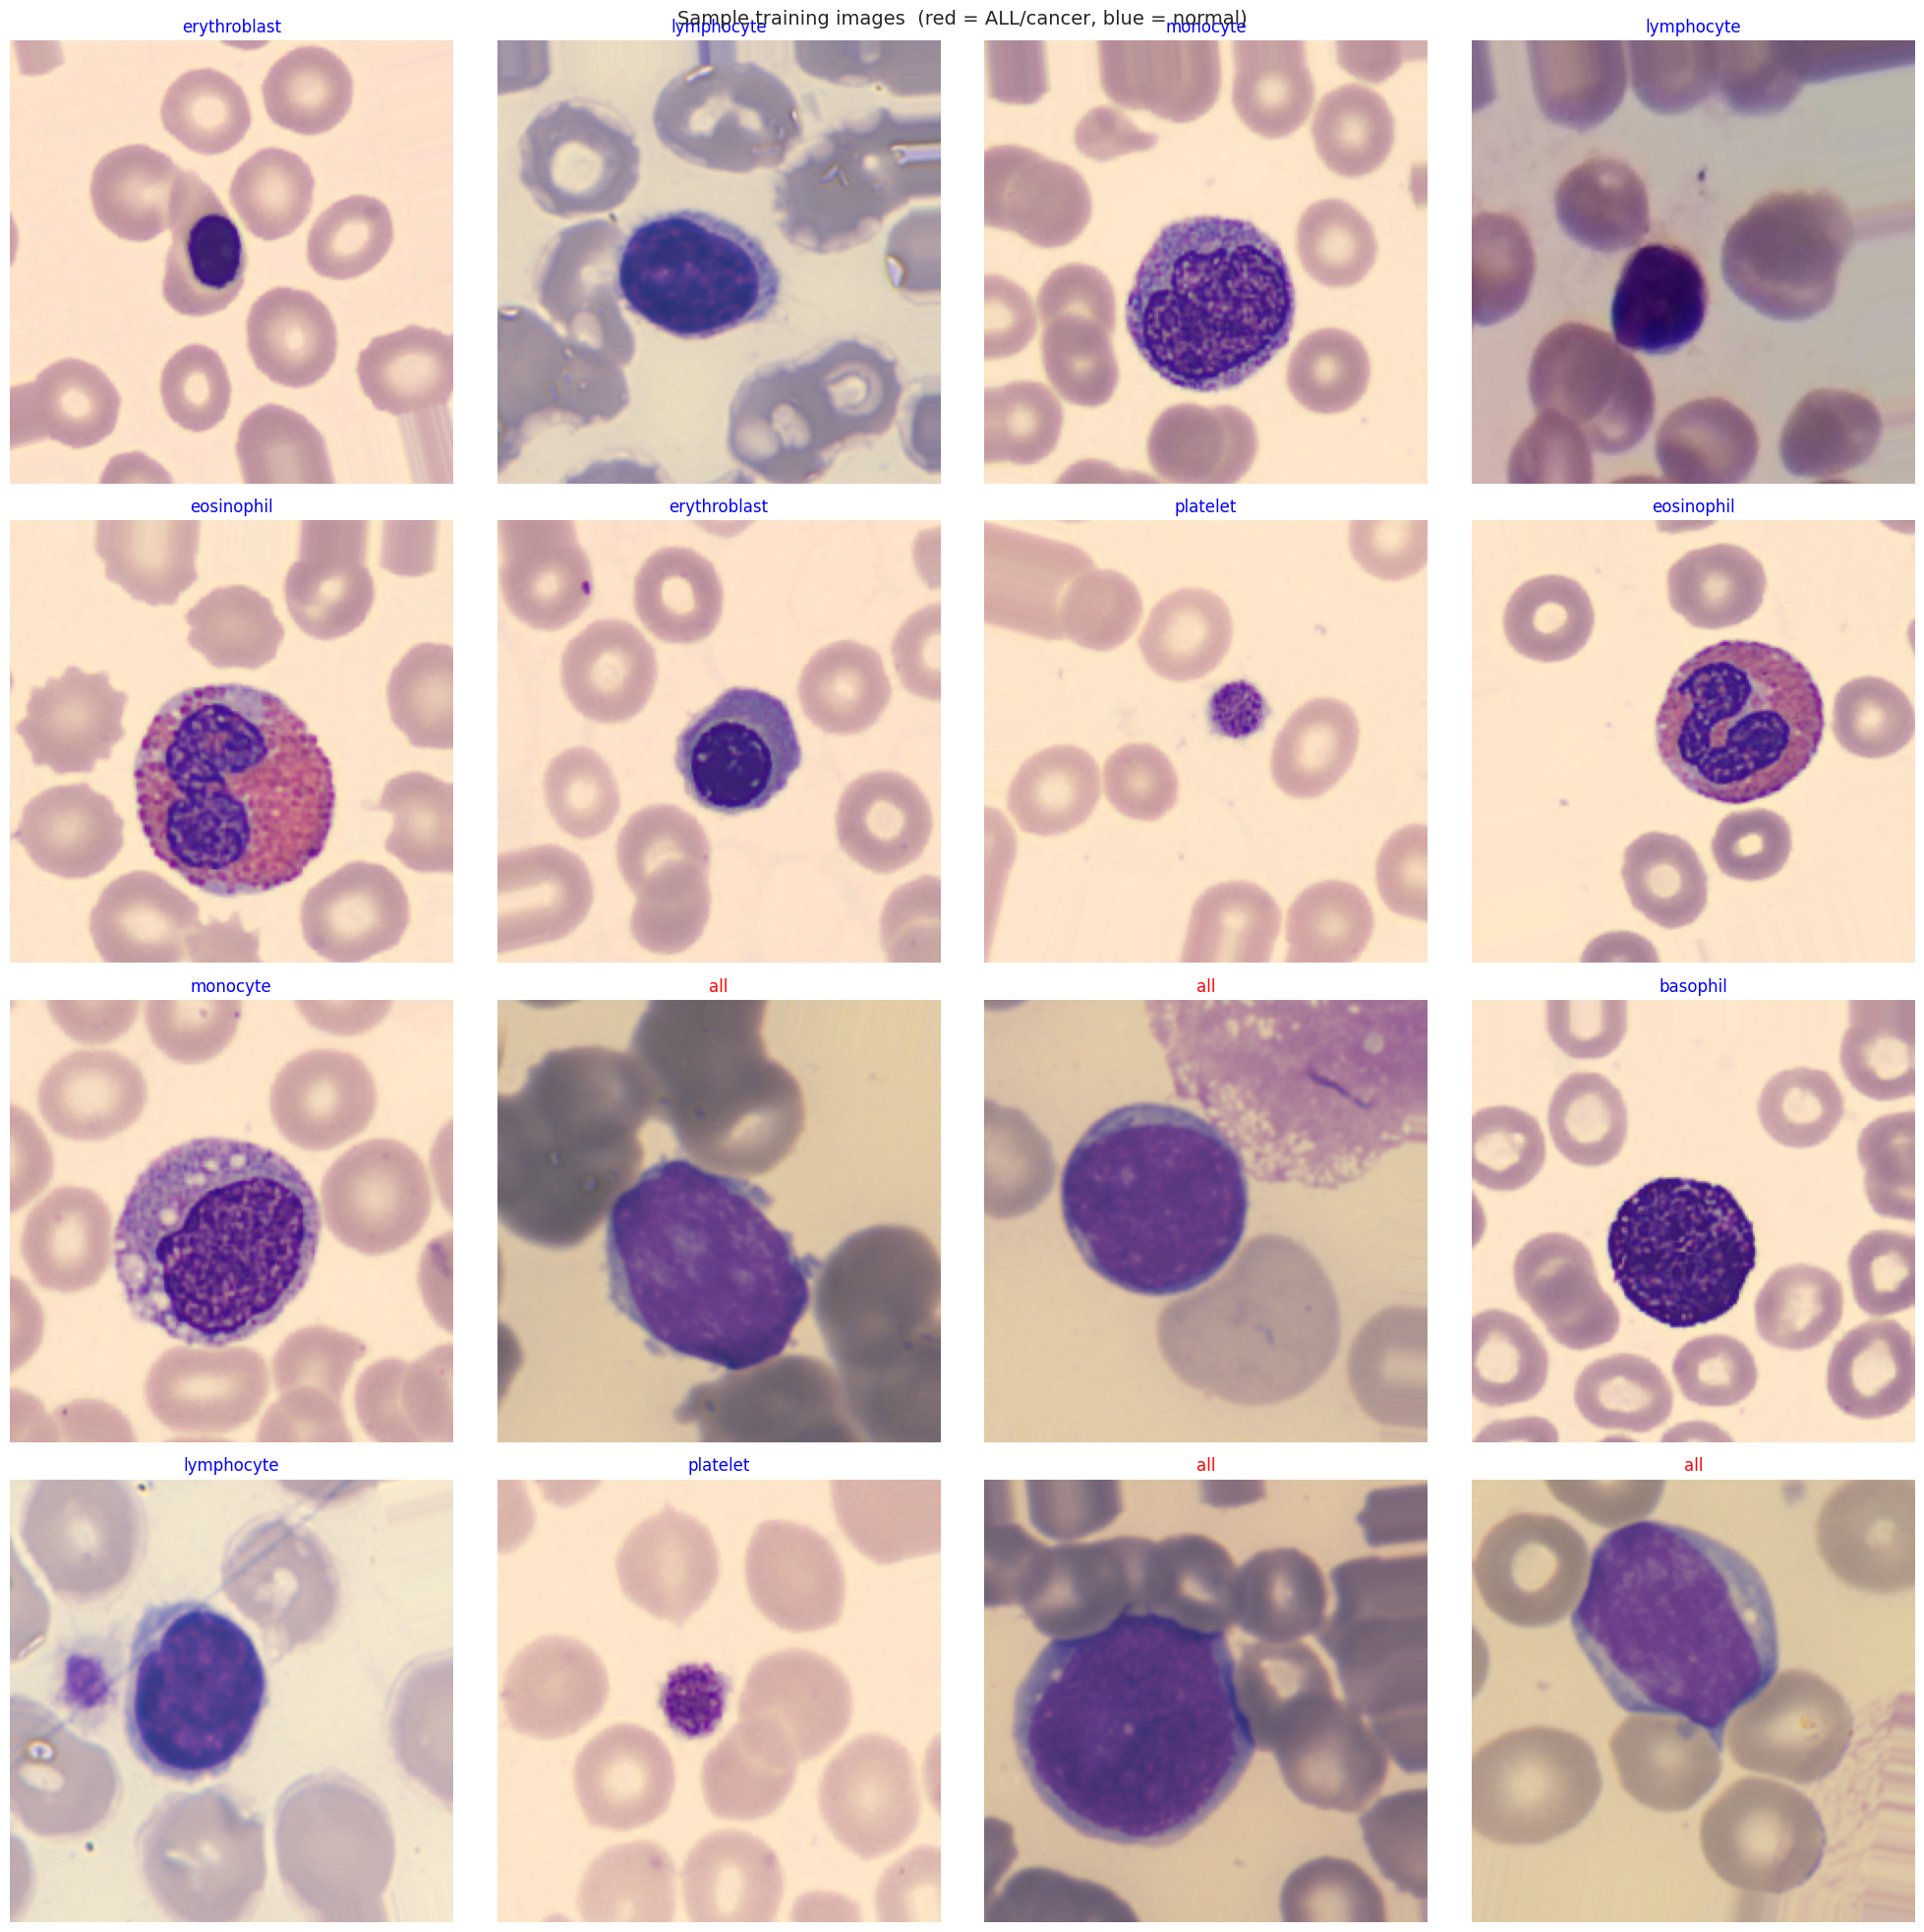

In [10]:
# 10. SHOW SAMPLE IMAGES FROM TRAINING SET
g_dict = train_gen.class_indices
classes = list(g_dict.keys())
images, label_batch = next(train_gen)

plt.figure(figsize=(20, 20))
for i in range(min(16, len(images))):
    plt.subplot(4, 4, i + 1)
    plt.imshow(images[i] / 255.0)
    class_name = classes[np.argmax(label_batch[i])]
    color = 'red' if class_name == 'all' else 'blue'
    plt.title(class_name, color=color, fontsize=12)
    plt.axis('off')
plt.suptitle('Sample training images  (red = ALL/cancer, blue = normal)', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Model Architecture

In [11]:
# 11. MODEL ARCHITECTURE — EfficientNetB3 + custom head
img_shape   = (IMG_SIZE[0], IMG_SIZE[1], 3)
class_count = len(classes)

base_model = tf.keras.applications.efficientnet.EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_shape=img_shape,
    pooling='max'
)

model = Sequential([
    base_model,
    BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
    Dense(256,
          kernel_regularizer=regularizers.l2(0.016),
          activity_regularizer=regularizers.l1(0.006),
          bias_regularizer=regularizers.l1(0.006),
          activation='relu'),
    Dropout(rate=0.45, seed=SEED),
    Dense(class_count, activation='softmax')
])

model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1779159673.081728      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779159673.087242      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,184,950 (42.67 MB)

 Trainable params: 11,094,575 (42.32 MB)

 Non-trainable params: 90,375 (353.03 KB)

## 12. Train Model

In [12]:
# 12. TRAIN MODEL
history = model.fit(
    x=train_gen,
    epochs=EPOCHS,
    verbose=1,
    validation_data=valid_gen,
    validation_steps=None,
    shuffle=False
)

Epoch 1/20


I0000 00:00:1779159727.056550      76 service.cc:152] XLA service 0x7836380048a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779159727.056589      76 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779159727.056593      76 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779159734.905209      76 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-19 03:02:29.400198: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 03:02:29.543870: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 03:02:29.889444: E external/local_xl

868/869 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.4103 - loss: 9.4835

2026-05-19 03:08:01.265802: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 03:08:01.406013: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 03:08:01.744761: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 03:08:01.891919: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 03:08:02.696169: E external/local_xla/xla/stream_

869/869 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.4103 - loss: 9.4803

2026-05-19 03:09:22.310463: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 03:09:22.448141: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 03:09:22.770013: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 03:09:22.916680: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 03:09:23.729991: E external/local_xla/xla/stream_

869/869 ━━━━━━━━━━━━━━━━━━━━ 492s 432ms/step - accuracy: 0.4102 - loss: 9.4770 - val_accuracy: 0.4552 - val_loss: 3.8901
Epoch 2/20
869/869 ━━━━━━━━━━━━━━━━━━━━ 201s 231ms/step - accuracy: 0.4091 - loss: 3.3446 - val_accuracy: 0.5060 - val_loss: 2.4887
Epoch 3/20
869/869 ━━━━━━━━━━━━━━━━━━━━ 191s 219ms/step - accuracy: 0.5195 - loss: 1.8964 - val_accuracy: 0.8902 - val_loss: 1.1912
Epoch 4/20
869/869 ━━━━━━━━━━━━━━━━━━━━ 188s 216ms/step - accuracy: 0.8586 - loss: 1.2261 - val_accuracy: 0.9396 - val_loss: 0.9530
Epoch 5/20
869/869 ━━━━━━━━━━━━━━━━━━━━ 187s 215ms/step - accuracy: 0.9093 - loss: 0.9663 - val_accuracy: 0.9880 - val_loss: 0.6222
Epoch 6/20
869/869 ━━━━━━━━━━━━━━━━━━━━ 186s 214ms/step - accuracy: 0.9080 - loss: 0.8521 - val_accuracy: 0.9703 - val_loss: 0.6256
Epoch 7/20
869/869 ━━━━━━━━━━━━━━━━━━━━ 195s 224ms/step - accuracy: 0.9033 - loss: 0.7765 - val_accuracy: 0.9823 - val_loss: 0.5101
Epoch 8/20
869/869 ━━━━━━━━━━━━━━━━━━━━ 185s 213ms/step - accuracy: 0.9077 - loss: 0.72

## 13. Training History

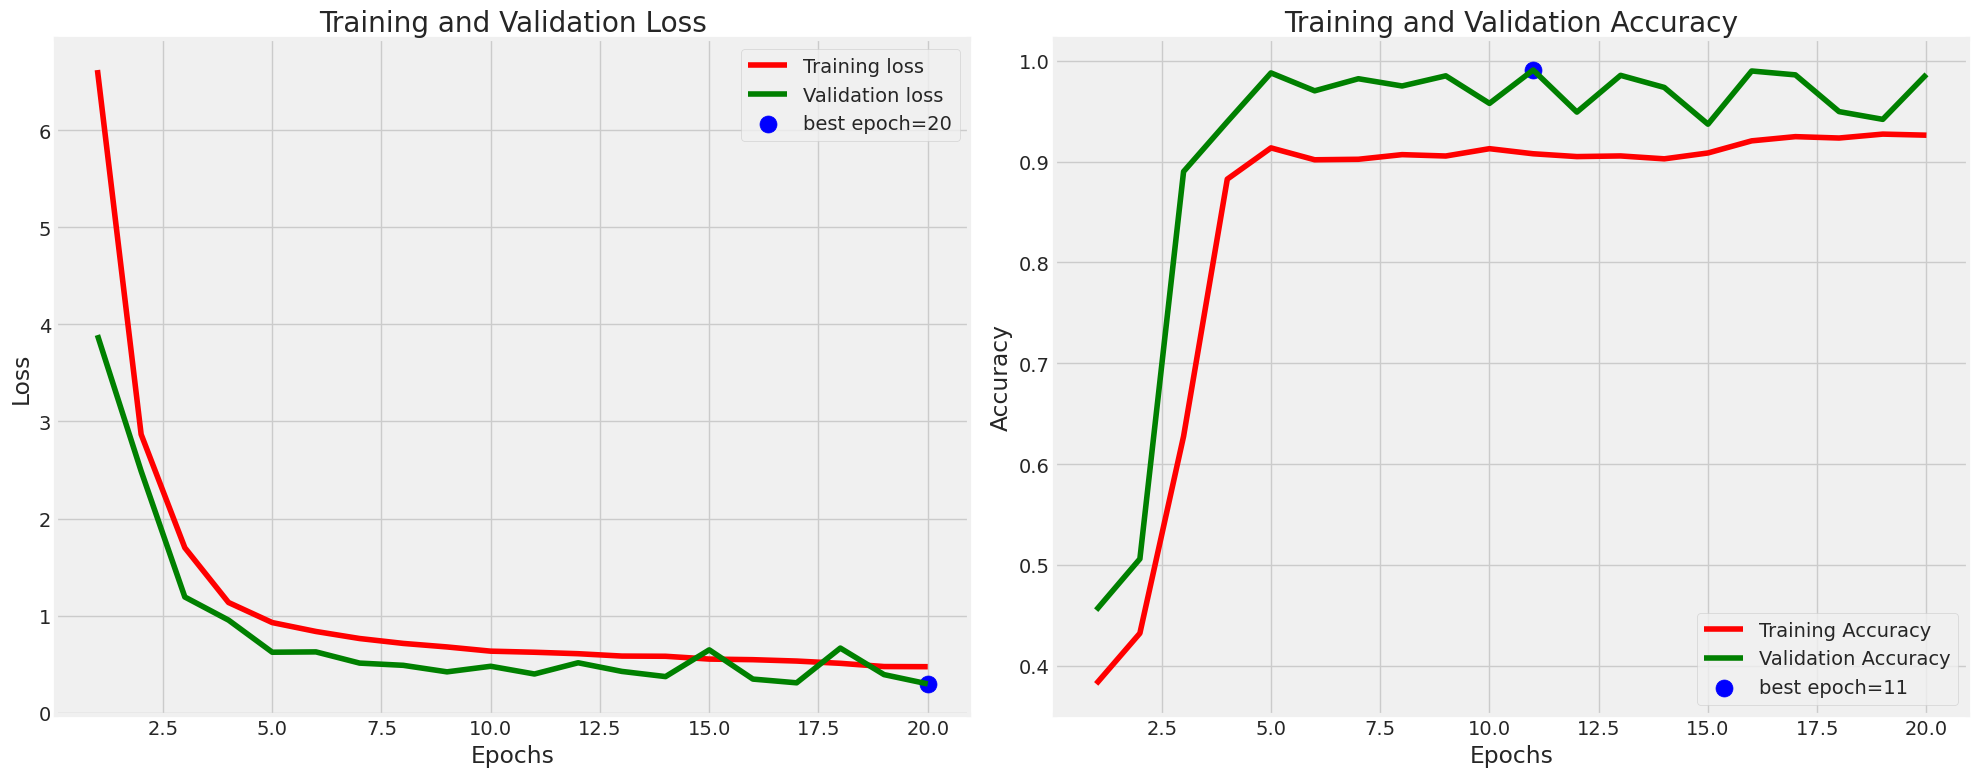

In [13]:
# 13. PLOT TRAINING HISTORY
tr_acc    = history.history['accuracy']
tr_loss   = history.history['loss']
val_acc   = history.history['val_accuracy']
val_loss  = history.history['val_loss']

index_loss  = np.argmin(val_loss)
index_acc   = np.argmax(val_acc)
Epochs_range = [i + 1 for i in range(len(tr_acc))]

plt.figure(figsize=(20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs_range, tr_loss,  'r', label='Training loss')
plt.plot(Epochs_range, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_loss[index_loss], s=150, c='blue',
            label=f'best epoch={index_loss+1}')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs_range, tr_acc,  'r', label='Training Accuracy')
plt.plot(Epochs_range, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, val_acc[index_acc], s=150, c='blue',
            label=f'best epoch={index_acc+1}')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## 14. Evaluate Model

In [14]:
# 14. EVALUATE MODEL
ts_length       = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1)
                               if ts_length % n == 0 and ts_length / n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps=test_steps, verbose=1)
valid_score = model.evaluate(valid_gen, steps=test_steps, verbose=1)
test_score  = model.evaluate(test_gen,  steps=test_steps, verbose=1)

print(f'Train Loss: {train_score[0]:.4f}  |  Train Accuracy: {train_score[1]:.4f}')
print('-' * 40)
print(f'Valid Loss: {valid_score[0]:.4f}  |  Valid Accuracy: {valid_score[1]:.4f}')
print('-' * 40)
print(f'Test  Loss: {test_score[0]:.4f}  |  Test  Accuracy: {test_score[1]:.4f}')

139/139 ━━━━━━━━━━━━━━━━━━━━ 28s 201ms/step - accuracy: 0.9958 - loss: 0.2614
139/139 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.9878 - loss: 0.2883
 86/139 ━━━━━━━━━━━━━━━━━━━━ 11s 212ms/step - accuracy: 0.9941 - loss: 0.2737

2026-05-19 04:10:05.459658: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 04:10:05.602390: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 04:10:05.944999: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 04:10:06.092526: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 04:10:06.895402: E external/local_xla/xla/stream_

139/139 ━━━━━━━━━━━━━━━━━━━━ 32s 231ms/step - accuracy: 0.9930 - loss: 0.2771
Train Loss: 0.2666  |  Train Accuracy: 0.9951
----------------------------------------
Valid Loss: 0.2962  |  Valid Accuracy: 0.9866
----------------------------------------
Test  Loss: 0.2825  |  Test  Accuracy: 0.9914


## 15. Predictions & Confusion Matrix

In [15]:
# 15. PREDICTIONS
preds  = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

87/87 ━━━━━━━━━━━━━━━━━━━━ 23s 161ms/step


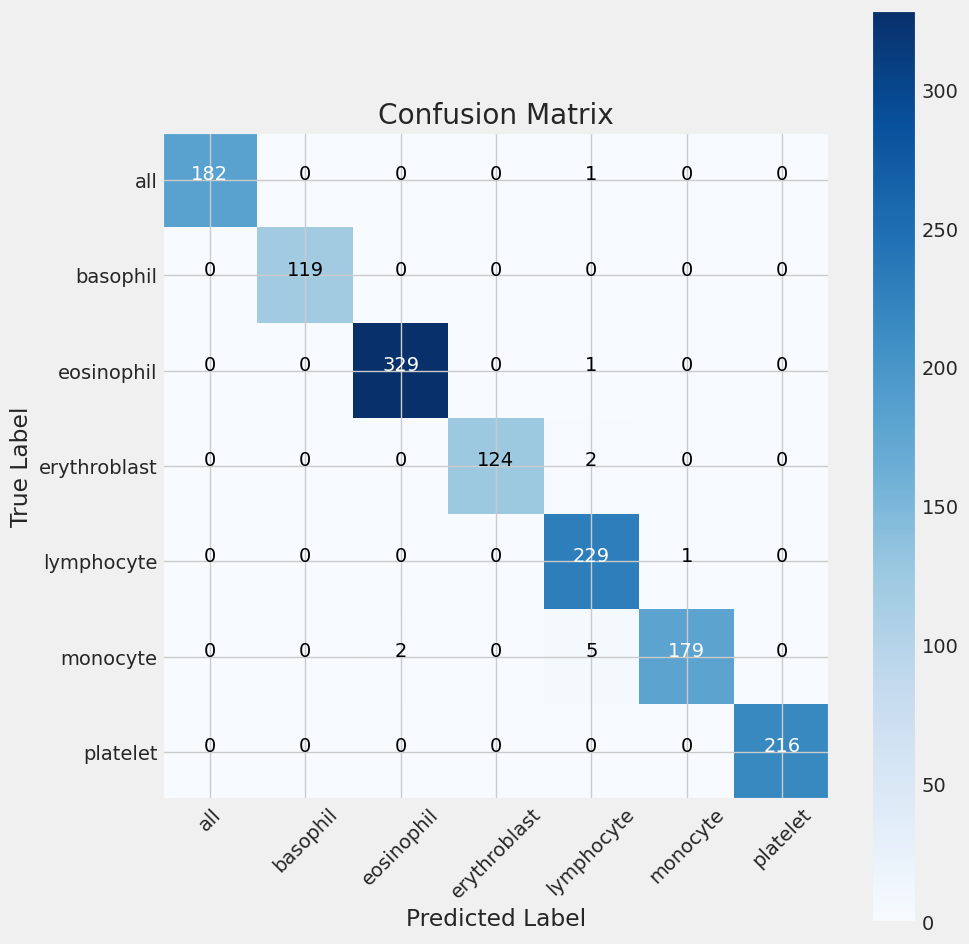

              precision    recall  f1-score   support

         all       1.00      0.99      1.00       183
    basophil       1.00      1.00      1.00       119
  eosinophil       0.99      1.00      1.00       330
erythroblast       1.00      0.98      0.99       126
  lymphocyte       0.96      1.00      0.98       230
    monocyte       0.99      0.96      0.98       186
    platelet       1.00      1.00      1.00       216

    accuracy                           0.99      1390
   macro avg       0.99      0.99      0.99      1390
weighted avg       0.99      0.99      0.99      1390



In [16]:
# 16. CONFUSION MATRIX
g_dict  = test_gen.class_indices
classes = list(g_dict.keys())
cm      = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(classification_report(test_gen.classes, y_pred, target_names=classes))

## 17. Save Model & Weights

In [17]:
# 17. SAVE MODEL & WEIGHTS
model.save('Bloods.keras')
model.save_weights('bloods_weights.weights.h5')

# Also save class index mapping so the server knows the label order
with open('class_indices.json', 'w') as f:
    json.dump(train_gen.class_indices, f, indent=2)

print('Saved:')
print('  Bloods.keras                  — full model (preferred)')
print('  bloods_weights.weights.h5     — weights only (fallback)')
print('  class_indices.json            — label → index mapping')
print()
print('Class indices:', train_gen.class_indices)
print('Download all three files from the Output tab.')

Saved:
  Bloods.keras                  — full model (preferred)
  bloods_weights.weights.h5     — weights only (fallback)
  class_indices.json            — label → index mapping

Class indices: {'all': 0, 'basophil': 1, 'eosinophil': 2, 'erythroblast': 3, 'lymphocyte': 4, 'monocyte': 5, 'platelet': 6}
Download all three files from the Output tab.
